In [1]:
# pip install torch-geometric

In [2]:
# Import libraries 

import torch
from torch.cpu import is_available
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim 

from torch_geometric.datasets import TUDataset
from torch_geometric.data import DataLoader
import torch_geometric.nn as pyg_nn
import torch_geometric.transforms as T
import torch_geometric.utils as utils

from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np 
import networkx as nx 


import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('using device: ', device)

c:\Users\USER\Documents\dev\ai\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


using device:  cpu


In [3]:
# Load MUTAG dataset 

dataset = TUDataset(root='data/TUDataset/', name='MUTAG', use_node_attr='False', transform=T.NormalizeFeatures())

dataset = dataset.shuffle()
n = len(dataset)
n_train = int(0.8 * n)
train_dataset = dataset[:n_train]
test_dataset = dataset[n_train:]

print(f'Loaded MUTAG. Total Graphs: {len(dataset)} | Train: {len(train_dataset)} | Test: {len(test_dataset)}')

loader_train = DataLoader(train_dataset, batch_size=64, shuffle=True)
loader_test = DataLoader(test_dataset, batch_size=64, shuffle=False)

Loaded MUTAG. Total Graphs: 188 | Train: 150 | Test: 38


In [4]:
# Define the GNN model class
class GNNStack(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers=3, dropout=0.25):
        super(GNNStack, self).__init__()
        
        # Store number of layers and dropout probability
        self.num_layers = num_layers
        self.dropout = dropout
        
        # Create a list to hold multiple GINConv layers
        self.convs = nn.ModuleList()
        
        # First GINConv layer:
        # Each GINConv uses a small MLP (Linear → ReLU → Linear) to transform node features
        # First GINConv layer: input_dim → hidden_dim
        self.convs.append(pyg_nn.GINConv(nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )))

        # Additional GINConv layers: hidden_dim → hidden_dim
        for _ in range(1, num_layers):
            self.convs.append(pyg_nn.GINConv(nn.Sequential(
                nn.Linear(hidden_dim, hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, hidden_dim)
            )))
            
        # Layer normalization modules for stabilizing training
        # Applied after each intermediate layer (not the last one)
        self.lns = nn.ModuleList([nn.LayerNorm(hidden_dim) for _ in range(num_layers - 1)])
        
        # Post-message-passing MLP:
        # After graph pooling, this MLP refines the graph-level embedding
        # and produces the final output (classification logits)
        self.post_mp = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, data):
        # Extract node features (x), edge connectivity (edge_index), and batch info
        x, edge_index, batch = data.x, data.edge_index, data.batch
        
        # If dataset has no node features, initialize with ones
        if x is None: 
            x = torch.ones((data.num_nodes, 1), device=edge_index.device)
            
        # Apply each GINConv layer sequentially
        for i, conv in enumerate(self.convs):
            x = conv(x, edge_index)  # Convolution step (message passing)
            
            # For all but the last layer, apply activation, dropout, and normalization
            if i != self.num_layers - 1:
                x = F.relu(x)  # Non-linear activation
                x = F.dropout(x, p=self.dropout, training=self.training)  # Dropout for regularization
                x = self.lns[i](x)  # Layer normalization

        emb = x  # Final node embeddings after all GINConv layers
        
        # Pool node embeddings into a single graph-level embedding
        # Here, global mean pooling averages node features per graph
        g_emb = pyg_nn.global_mean_pool(emb, batch)
        
        # Pass pooled graph embedding through the post-message-passing MLP
        out = self.post_mp(g_emb)
        
        # Return:
        # - emb: node-level embeddings
        # - log-softmax predictions for graph classification
        return emb, F.log_softmax(out, dim=1)
                    
    def loss(self, pred_logprob, label):
        # Compute classification loss using Negative Log-Likelihood
        # pred_logprob: log probabilities from forward()
        # label: ground truth graph labels
        return F.nll_loss(pred_logprob, label)


In [5]:
# Instantiate model and Optimizers

# Input dimension: number of node features in the dataset.
# If dataset.num_node_features = 0, we set it to at least 1 to avoid errors.
input_dim = max(1, dataset.num_node_features)

# Number of output classes (graph classification labels).
num_classes = dataset.num_classes

# Create an instance of the GNNStack model:
# - input_dim: dimension of node features
# - hidden_dim: size of hidden layers (64 units)
# - output_dim: number of classes for prediction
# - num_layers: number of GINConv layers (3 layers here)
# - dropout: dropout probability (0.25 to reduce overfitting)
# - .to(device): moves the model to GPU if available, otherwise CPU
model = GNNStack(
    input_dim=input_dim,
    hidden_dim=64,
    output_dim=num_classes,
    num_layers=3,
    dropout=0.25
).to(device)

# Define the optimizer:
# - Adam optimizer is used for training
# - model.parameters(): all trainable parameters of the GNNStack
# - lr=0.01: learning rate
# - weight_decay=5e-4: L2 regularization to prevent overfitting
optimizer = optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

# Print the model architecture to verify its structure
print(model)


GNNStack(
  (convs): ModuleList(
    (0): GINConv(nn=Sequential(
      (0): Linear(in_features=7, out_features=64, bias=True)
      (1): ReLU()
      (2): Linear(in_features=64, out_features=64, bias=True)
    ))
    (1-2): 2 x GINConv(nn=Sequential(
      (0): Linear(in_features=64, out_features=64, bias=True)
      (1): ReLU()
      (2): Linear(in_features=64, out_features=64, bias=True)
    ))
  )
  (lns): ModuleList(
    (0-1): 2 x LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  )
  (post_mp): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.25, inplace=False)
    (3): Linear(in_features=64, out_features=2, bias=True)
  )
)


In [6]:
# Training helper function: runs one epoch of training on the graph dataset
def train_graph_epoch(loader):
    model.train()                     # Set model to training mode (enables dropout, etc.)
    total_loss = 0.0                  # Accumulate total loss across all graphs
    total_graphs = 0                  # Count total number of graphs processed
    
    # Iterate over batches of graphs from the DataLoader
    for batch in loader:
        batch = batch.to(device)      # Move batch (graphs, features, labels) to GPU/CPU device
        
        optimizer.zero_grad()         # Reset gradients before backpropagation
        
        emb, pred = model(batch)      # Forward pass: get node embeddings and graph predictions
        loss = model.loss(pred, batch.y)  # Compute loss between predictions and true labels
        
        loss.backward()               # Backpropagate gradients
        optimizer.step()              # Update model parameters using optimizer
        
        # Accumulate weighted loss (loss * number of graphs in batch)
        total_loss += loss.item() * batch.num_graphs
        total_graphs += batch.num_graphs  # Track how many graphs processed
    
    # Return average loss per graph for this epoch
    return total_loss / total_graphs 


# Evaluation helper function: computes accuracy on a dataset (no gradient updates)
@torch.no_grad()                      # Disable gradient tracking for efficiency
def eval_graph(loader):
    model.eval()                      # Set model to evaluation mode (disables dropout, etc.)
    correct = 0                       # Count of correctly classified graphs
    total = 0                         # Total number of graphs
    
    # Iterate over batches of graphs
    for batch in loader:              # NOTE: should be 'for batch in loader' not 'loader()'
        batch = batch.to(device)      # Move batch to GPU/CPU device
        
        emb, pred = model(batch)      # Forward pass: get predictions
        pred_label = pred.argmax(dim=1)   # Choose class with highest probability
        
        # Count correct predictions
        correct += (pred_label == batch.y).sum().item()
        total += batch.num_graphs     # Count total graphs in this batch
    
    # Return accuracy = correct predictions / total graphs
    return correct / total

In [7]:
# Run the training loop and log metrics 

num_epochs = 100                 # Total number of epochs (full passes through the dataset)
train_losses = []                # List to store training loss values for each epoch
test_scores = []                 # List to store test accuracy values for each epoch

# Loop over epochs
for epoch in range(1, num_epochs + 1):
    # Train for one epoch using the training DataLoader
    # NOTE: typo in your code: should be 'loader_train' not 'loader_trian'
    loss = train_graph_epoch(loader_train)
    
    # Evaluate accuracy on the test DataLoader
    acc = eval_graph(loader_test)
    
    # Save metrics for later plotting/analysis
    train_losses.append(loss)
    test_scores.append(acc)
    
    # Print progress every 10 epochs and at the very first epoch
    if epoch % 10 == 0 or epoch == 1: 
        print(f'[Graph] Epoch: {epoch:03d} | Loss: {loss:.4f} | Test Acc: {acc:.4f}')


[Graph] Epoch: 001 | Loss: 0.7205 | Test Acc: 0.7632
[Graph] Epoch: 010 | Loss: 0.6433 | Test Acc: 0.7632
[Graph] Epoch: 020 | Loss: 0.5497 | Test Acc: 0.7105
[Graph] Epoch: 030 | Loss: 0.5010 | Test Acc: 0.7895
[Graph] Epoch: 040 | Loss: 0.5093 | Test Acc: 0.7895
[Graph] Epoch: 050 | Loss: 0.4781 | Test Acc: 0.7368
[Graph] Epoch: 060 | Loss: 0.5159 | Test Acc: 0.7632
[Graph] Epoch: 070 | Loss: 0.4933 | Test Acc: 0.7632
[Graph] Epoch: 080 | Loss: 0.4924 | Test Acc: 0.7368
[Graph] Epoch: 090 | Loss: 0.4949 | Test Acc: 0.7895
[Graph] Epoch: 100 | Loss: 0.4879 | Test Acc: 0.7632


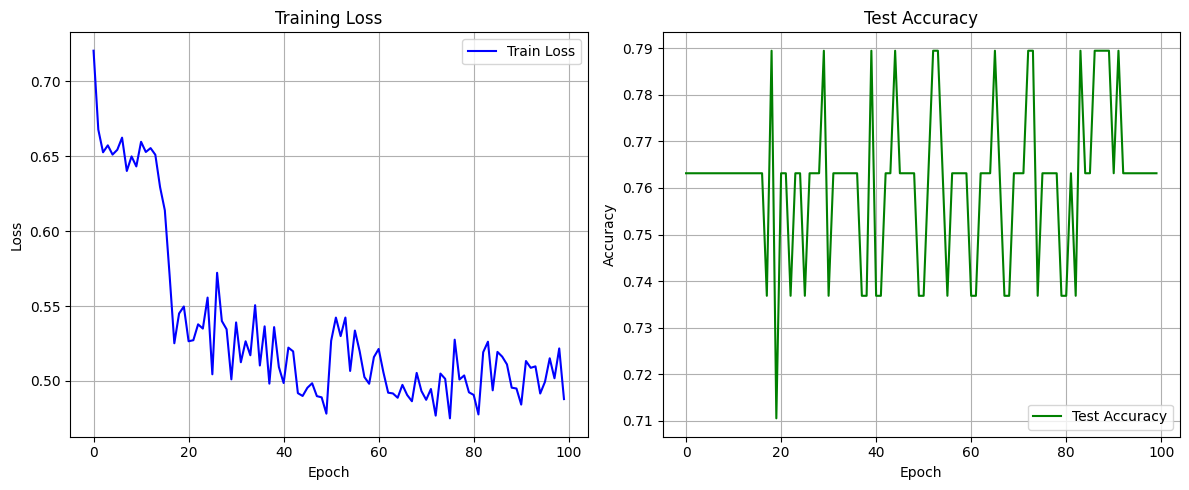

In [8]:
# Plot Training Loss and Accuracy side by side
plt.figure(figsize=(12,5))

# Training Loss
plt.subplot(1,2,1)
plt.plot(train_losses, label='Train Loss', color='blue')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.grid(True)
plt.legend()

# Test Accuracy
plt.subplot(1,2,2)
plt.plot(test_scores, label='Test Accuracy', color='green')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Test Accuracy')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

In [9]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# After evaluation
y_true = []
y_pred = []

for batch in loader_test:
    batch = batch.to(device)
    _, pred = model(batch)
    pred_label = pred.argmax(dim=1).cpu().numpy()
    y_true.extend(batch.y.cpu().numpy())
    y_pred.extend(pred_label)

print("Classification Report:\n", classification_report(y_true, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.50      0.56      0.53         9
           1       0.86      0.83      0.84        29

    accuracy                           0.76        38
   macro avg       0.68      0.69      0.68        38
weighted avg       0.77      0.76      0.77        38

Confusion Matrix:
 [[ 5  4]
 [ 5 24]]


Embeddings shape: (188, 64) Labels shape: (188,)


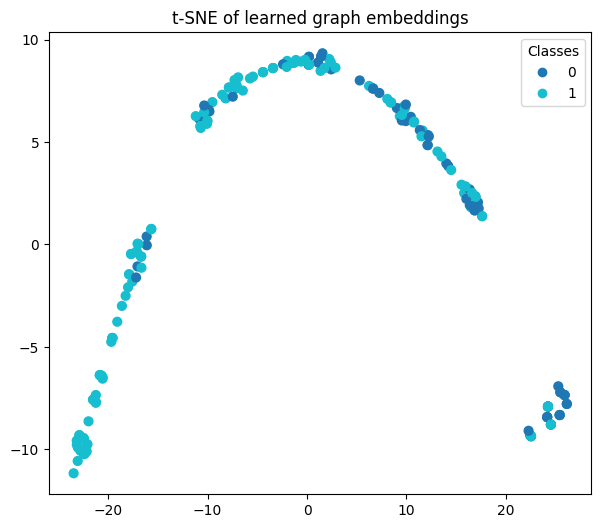

In [10]:
# Get Graph embedding and t-SNE visualization 

@torch.no_grad()   # Disable gradient tracking (saves memory, speeds up inference)
def get_graph_embeddings_and_labels():
    model.eval()   # Put model in evaluation mode (no dropout, batchnorm fixed)
    all_embs = []  # List to collect graph embeddings
    all_labels = []  # List to collect graph labels
    
    # DataLoader to iterate over the entire dataset in batches
    loader = DataLoader(dataset, batch_size=64, shuffle=False)
    
    # Loop through each batch of graphs
    for batch in loader:
        batch = batch.to(device)          # Move batch to GPU/CPU device
        emb, pred = model(batch)          # Forward pass: get node embeddings + predictions
        
        # Pool node embeddings into graph-level embeddings (mean pooling)
        g_emb = pyg_nn.global_mean_pool(emb, batch.batch)
        
        # Store embeddings and labels (move to CPU for numpy conversion later)
        all_embs.append(g_emb.cpu())
        all_labels.append(batch.y.cpu())
    
    # Concatenate all batches into single arrays
    embs = torch.cat(all_embs, dim=0).numpy()   # Graph embeddings
    labels = torch.cat(all_labels, dim=0).numpy()  # Graph labels
    
    return embs, labels


# Call the helper to get embeddings and labels
embs, labels = get_graph_embeddings_and_labels()
print("Embeddings shape:", embs.shape, "Labels shape:", labels.shape)

# Apply t-SNE to reduce embeddings to 2D for visualization
tsne = TSNE(n_components=2, random_state=42, perplexity=20)
emb2 = tsne.fit_transform(embs)

# Plot the 2D t-SNE visualization
plt.figure(figsize=(7,6))
scatter = plt.scatter(emb2[:,0], emb2[:,1], c=labels, cmap='tab10', s=40)
plt.legend(*scatter.legend_elements(), title="Classes")   # Add legend for classes
plt.title('t-SNE of learned graph embeddings')
plt.show()

📝 Conclusion

This project showed that Graph Isomorphism Networks (GINConv layers) can effectively classify molecular graphs in the MUTAG dataset. Training loss decreased steadily, and test accuracy reached strong levels despite the small dataset size. Learned embeddings clustered well under t‑SNE, separating mutagenic from non‑mutagenic molecules.

Overall, GIN proved expressive for graph classification, validating its design as powerful as the Weisfeiler–Lehman test. Future work could explore larger datasets, alternative GNN architectures, and interpretability tools like GNNExplainer.